# Classification of Music by Genre - Brian Miller - August/September 2026

## Part 2: Neural-Networks

### 2.0.0. Imports Used in This Notebook:

In [1]:
import matplotlib.pyplot as plt

import numpy as np, pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import time


2026-09-10 12:56:14.598855: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 2.0.1. Reusable Helper Methods Used in This Notebook:

In [2]:
# Reusable evaluation: returns one results row in the same schema as all_results.csv
def evaluate_keras_model(fitted_model, X_te, y_te, name, training_time, tuning_time=np.nan):
    y_prob = fitted_model.predict(X_te, verbose=0)      # softmax scores, needed for AUC
    y_pred = np.argmax(y_prob, axis=1)                  # hard labels, needed for everything else
    y_bin = label_binarize(y_te, classes=range(num_classes))
    row = pd.DataFrame({
        'Model': [name],
        'Family': ['Neural Network'],
        'Test Accuracy': [accuracy_score(y_te, y_pred)],
        'Precision (macro)': [precision_score(y_te, y_pred, average='macro')],
        'Recall (macro)': [recall_score(y_te, y_pred, average='macro')],
        'F1 (macro)': [f1_score(y_te, y_pred, average='macro')],
        'Macro AUC': [roc_auc_score(y_bin, y_prob, average='macro', multi_class='ovr')],
        'Micro AUC': [roc_auc_score(y_bin, y_prob, average='micro')],
        'Training Time (s)': [training_time],
        'Tuning Time (s)': [tuning_time],
        'Complexity': [fitted_model.count_params()],
        'Complexity Measure': ['total parameters']
    })
    return row, y_pred, y_prob


# Reusable: confusion matrix plus one-vs-rest ROC curves for any model's predictions
def plot_confusion_and_roc(y_true, y_pred, y_prob, title):
    fig, ax = plt.subplots(figsize=(8, 8))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=labelencoder.classes_,
                                            xticks_rotation=45, cmap='Blues', ax=ax)
    ax.set_title(f'{title} Confusion Matrix')
    plt.show()

    # One binary column per class: 1 where the true label is that class, 0 otherwise
    y_bin = label_binarize(y_true, classes=range(num_classes))

    plt.figure(figsize=(8, 6))
    for i, label in enumerate(labelencoder.classes_):
        # Class i treated as positive, all other genres as negative
        fpr_i, tpr_i, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        plt.plot(fpr_i, tpr_i, label=f'{label} (AUC = {auc(fpr_i, tpr_i):.2f})')
    plt.plot([0, 1], [0, 1], 'k--')          # chance line for reference
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title(f'{title}: One-vs-Rest ROC Curves'); plt.legend(fontsize=8)
    plt.show()

    print(f'macro_auc = {roc_auc_score(y_bin, y_prob, average="macro", multi_class="ovr"):.4f}')
    print(f'micro_auc = {roc_auc_score(y_bin, y_prob, average="micro"):.4f}')

### 2.1.  Basic Feed-Forward Neural Network:

In [3]:


# Same GTZAN feature table used in Part 1, so results are comparable
df = pd.read_csv('GTZAN_Data_Music_Genre_Classification/features_30_sec.csv')
# df = df.drop(columns=['filename']).drop_duplicates().dropna()
df = df.drop(columns=['filename'])
df = df.drop(columns=[c for c in df.columns if df[c].nunique() == 1])  # drop constant cols
X = df.iloc[:, :-1].astype('float32')    # numeric audio features
y = df.iloc[:, -1]                       # genre label (text)

labelencoder = LabelEncoder()            # blues -> 0, classical -> 1, ...
y = labelencoder.fit_transform(y)
num_classes = len(labelencoder.classes_)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()                # NN training needs scaled inputs
X_train = scaler.fit_transform(X_train).astype('float32')
X_test = scaler.transform(X_test).astype('float32')
print(f'X_train.shape = {X_train.shape}')
print(f'X_test.shape = {X_test.shape}')
print(f'num_classes = {num_classes}')
print(f'labelencoder.classes_ = {labelencoder.classes_}')

X_train.shape = (800, 58)
X_test.shape = (200, 58)
num_classes = 10
labelencoder.classes_ = ['blues' 'classical' 'country' 'disco' 'hiphop' 'jazz' 'metal' 'pop'
 'reggae' 'rock']


### 2.1.1.  Basic Feed-Forward Network: Define and Compile:

In [4]:
# Basic feed-forward net: 58 features -> 256 -> 128 -> 10 genres, with dropout

tf.keras.utils.set_random_seed(42)   # same seed convention as Part 1

model = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()
print(f'total_params = {model.count_params()}')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        15,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,290 (192.54 KB)

 Trainable params: 49,290 (192.54 KB)

 Non-trainable params: 0 (0.00 B)

total_params = 49290


### 2.1.2.  Basic Feed-Forward Neural Network: Training the Model:

In [5]:
# Train with early stopping on a validation split, timed like the Part 1 models


early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

nn_start_time = time.time()
history = model.fit(X_train, y_train,
                    validation_split=0.2,
                    epochs=200,
                    batch_size=32,
                    callbacks=[early_stop],
                    verbose=0)
nn_end_time = time.time()
nn_training_time = nn_end_time - nn_start_time

print(f'NN training time = {nn_training_time:.2f} seconds')
print(f'epochs_run = {len(history.history["loss"])}')


NN training time = 4.64 seconds
epochs_run = 35


### 2.1.3. Basic Feed-Forward Neural Network: Learning Curves:

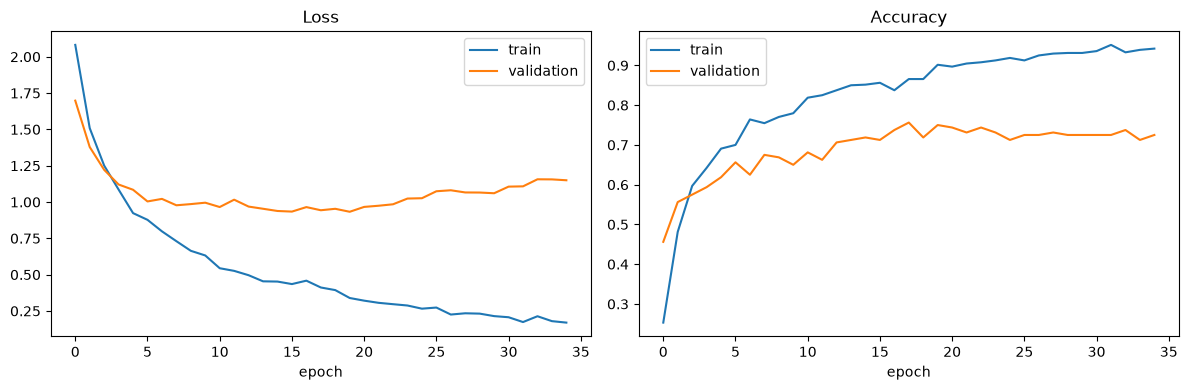

best_epoch = 20 of 35
val_accuracy_at_best_epoch = 0.7500


In [6]:
# Learning curves: check for overfitting and confirm early stopping chose a sensible epoch


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='validation')
axes[0].set_title('Loss'); axes[0].set_xlabel('epoch'); axes[0].legend()
axes[1].plot(history.history['accuracy'], label='train')
axes[1].plot(history.history['val_accuracy'], label='validation')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('epoch'); axes[1].legend()
plt.tight_layout(); plt.show()

best_epoch = int(np.argmin(history.history['val_loss'])) + 1
print(f'best_epoch = {best_epoch} of {len(history.history["loss"])}')
print(f'val_accuracy_at_best_epoch = {history.history["val_accuracy"][best_epoch - 1]:.4f}')


### 2.1.4. Basic Feed-Forward Neural Network: Predictions:

In [7]:
# Predict on the untouched test set (mirrors Part 1 sections 1.1.2 - 1.1.3)
from sklearn.metrics import accuracy_score

y_pred_nn = np.argmax(model.predict(X_test, verbose=0), axis=1)
train_accuracy_nn = accuracy_score(y_train, np.argmax(model.predict(X_train, verbose=0), axis=1))
nn_accuracy = accuracy_score(y_test, y_pred_nn)

print(f'Predictions shape = {y_pred_nn.shape}')
print(f'First 10 predicted = {y_pred_nn[:10]}')
print(f'First 10 actual    = {y_test[:10]}')
print(f'NN Training accuracy = {train_accuracy_nn:.4f}')
print(f'NN Testing accuracy  = {nn_accuracy:.4f}')

Predictions shape = (200,)
First 10 predicted = [1 0 3 5 0 9 2 2 4 5]
First 10 actual    = [1 0 6 5 0 2 9 2 4 5]
NN Training accuracy = 0.9213
NN Testing accuracy  = 0.7750


### 2.1.5. Basic Feed-Forward Neural Network: Precision, Recall, F1:

In [8]:
# Macro precision, recall, F1 and confusion matrix (mirrors Part 1 sections 1.1.4 - 1.1.5)
from sklearn.metrics import precision_score, recall_score, f1_score, ConfusionMatrixDisplay

nn_precision = precision_score(y_test, y_pred_nn, average='macro')
nn_recall    = recall_score(y_test, y_pred_nn, average='macro')
nn_f1        = f1_score(y_test, y_pred_nn, average='macro')

print(f'nn_precision = {nn_precision:.4f}')
print(f'nn_recall    = {nn_recall:.4f}')
print(f'nn_f1        = {nn_f1:.4f}')

nn_precision = 0.7790
nn_recall    = 0.7750
nn_f1        = 0.7715


## 2.1.6. Basic Feed-Forward Neural Network: Confusion Matrix:

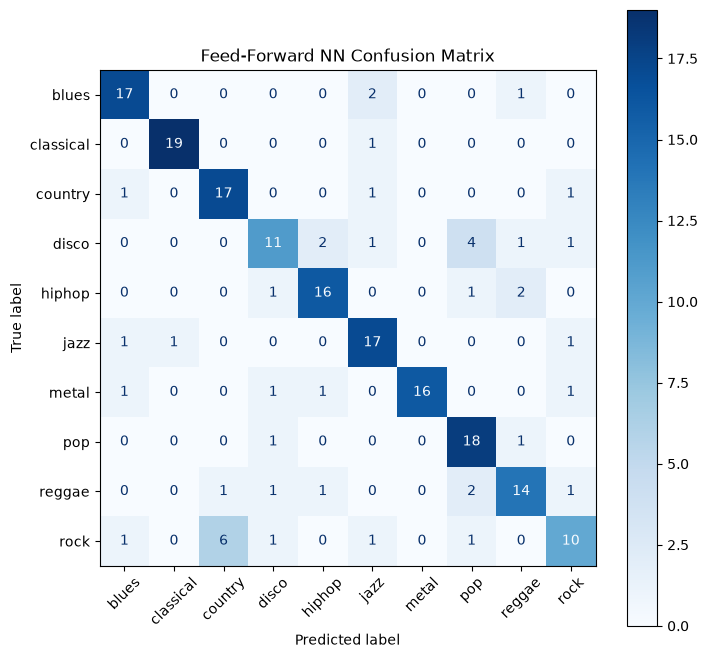

In [9]:
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_nn, display_labels=labelencoder.classes_,
                                        xticks_rotation=45, cmap='Blues', ax=ax)
ax.set_title('Feed-Forward NN Confusion Matrix')
plt.show()

### 2.1.7. Basic Feed-Forward Neural Network: ROC curves and macro/micro AUC

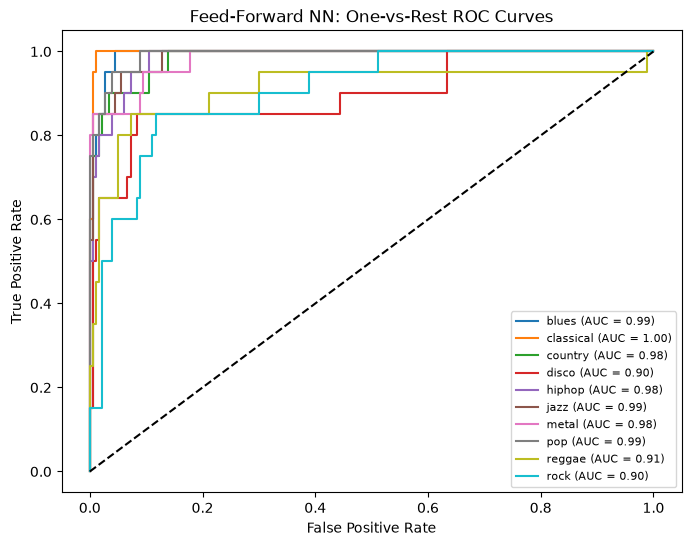

roc_auc_macro_nn = 0.9623
roc_auc_micro_nn = 0.9648


In [10]:
# One-vs-rest ROC curves and macro/micro AUC (mirrors Part 1 section 1.1.6)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

y_score_nn = model.predict(X_test, verbose=0)
y_test_bin = label_binarize(y_test, classes=range(num_classes))

fpr_nn, tpr_nn, roc_auc_nn = {}, {}, {}
for i in range(num_classes):
    fpr_nn[i], tpr_nn[i], _ = roc_curve(y_test_bin[:, i], y_score_nn[:, i])
    roc_auc_nn[i] = auc(fpr_nn[i], tpr_nn[i])

plt.figure(figsize=(8, 6))
for i, label in enumerate(labelencoder.classes_):
    plt.plot(fpr_nn[i], tpr_nn[i], label=f'{label} (AUC = {roc_auc_nn[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('Feed-Forward NN: One-vs-Rest ROC Curves'); plt.legend(fontsize=8)
plt.show()

roc_auc_macro_nn = roc_auc_score(y_test_bin, y_score_nn, average='macro', multi_class='ovr')
roc_auc_micro_nn = roc_auc_score(y_test_bin, y_score_nn, average='micro')
print(f'roc_auc_macro_nn = {roc_auc_macro_nn:.4f}')
print(f'roc_auc_micro_nn = {roc_auc_micro_nn:.4f}')

### Store Results So Far to File (Part 1 + Feed-Forward NN):

In [11]:
# Bank the feed-forward results in the same schema as part1_results.csv
part1_results = pd.read_csv('part1_results.csv')

nn_row = pd.DataFrame({
    'Model': ['Feed-Forward NN'],
    'Family': ['Neural Network'],
    'Test Accuracy': [nn_accuracy],
    'Precision (macro)': [nn_precision],
    'Recall (macro)': [nn_recall],
    'F1 (macro)': [nn_f1],
    'Macro AUC': [roc_auc_macro_nn],
    'Micro AUC': [roc_auc_micro_nn],
    'Training Time (s)': [nn_training_time],
    'Tuning Time (s)': [np.nan],
    'Complexity': [model.count_params()],
    'Complexity Measure': ['total parameters']
})

results = pd.concat([part1_results, nn_row], ignore_index=True)
results.to_csv('all_results.csv', index=False)
print(f'results.shape = {results.shape}')
results

results.shape = (5, 12)


,Model,Family,Test Accuracy,Precision (macro),Recall (macro),F1 (macro),Macro AUC,Micro AUC,Training Time (s),Tuning Time (s),Complexity,Complexity Measure
0,SVM,Classical ML,0.765,0.768611,0.765,0.764319,0.943611,0.945317,0.032251,11.890773,38454,support vectors x features
1,Random Forest,Classical ML,0.820,0.820470,0.820,0.818040,0.975306,0.976993,0.497786,106.945784,75074,decision nodes
2,k-NN,Classical ML,0.690,0.707873,0.690,0.690255,0.905028,0.905900,0.002672,0.396208,800,stored samples
3,Gradient Boosting,Classical ML,0.795,0.802499,0.795,0.794836,0.978222,0.978806,9.974431,3234.812495,2076,decision nodes
4,Feed-Forward NN,Neural Network,0.775,0.779030,0.775,0.771468,0.962278,0.964769,4.643466,NaN,49290,total parameters


### NOTE: Comparisons to Part 1 Algorithms:

The above Basic Feed-Forward Neural Network reaches 0.775 with 49,290 parameters in ~~6~~ 4.6 seconds versus Random Forest (see Part 1 notebook file) which reached 0.820 with 75,074 decision nodes.

The 0.92 versus 0.775 train-test gap points to data volume as the binding constraint.


## 2.1.8. Basic Feed-Forward Neural Network: Hyper-Parameter Tuning:

In [12]:
# Parameterized feed-forward builder; defaults reproduce the 2.1.1 architecture exactly
def build_ffnn(hidden=(256, 128), dropout=0.3, learning_rate=1e-3):
    tf.keras.utils.set_random_seed(42)
    ffnn = models.Sequential([layers.Input(shape=(X_train.shape[1],))])
    for units in hidden:
        ffnn.add(layers.Dense(units, activation='relu'))
        ffnn.add(layers.Dropout(dropout))
    ffnn.add(layers.Dense(num_classes, activation='softmax'))
    ffnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])
    return ffnn

In [13]:
# Compare feed-forward configurations on a fixed validation set (parallels GridSearchCV in Part 1).
# A single held-out split, rather than Keras's validation_split, so every config sees the same data.
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2,
                                            random_state=42, stratify=y_train)

ffnn_grid = [
    {'hidden': (128,),            'dropout': 0.3, 'learning_rate': 1e-3},
    {'hidden': (256, 128),        'dropout': 0.3, 'learning_rate': 1e-3},   # the 2.1 baseline
    {'hidden': (256, 128),        'dropout': 0.5, 'learning_rate': 1e-3},
    {'hidden': (512, 256),        'dropout': 0.5, 'learning_rate': 3e-4},
    {'hidden': (512, 256, 128),   'dropout': 0.5, 'learning_rate': 3e-4},
]

rows = []
ffnn_tuning_start_time = time.time()
for i, cfg in enumerate(ffnn_grid):
    candidate = build_ffnn(**cfg)                    # fresh weights every iteration
    es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    h = candidate.fit(X_tr, y_tr, validation_data=(X_val, y_val),
                      epochs=200, batch_size=32, callbacks=[es], verbose=0)
    best = int(np.argmin(h.history['val_loss']))     # the epoch whose weights were restored
    rows.append({'idx': i, 'hidden': str(cfg['hidden']), 'dropout': cfg['dropout'],
                 'learning_rate': cfg['learning_rate'],
                 'val_accuracy': h.history['val_accuracy'][best],
                 'epochs_run': len(h.history['loss']),
                 'params': candidate.count_params()})
ffnn_tuning_time = time.time() - ffnn_tuning_start_time

ffnn_tuning_results = pd.DataFrame(rows).sort_values('val_accuracy', ascending=False)
print(f'ffnn_tuning_time = {ffnn_tuning_time:.2f} seconds')
ffnn_tuning_results

ffnn_tuning_time = 36.29 seconds


,idx,hidden,dropout,learning_rate,val_accuracy,epochs_run,params
1,1,"(256, 128)",0.3,0.0010,0.76875,34,49290
0,0,"(128,)",0.3,0.0010,0.76250,48,8842
3,3,"(512, 256)",0.5,0.0003,0.76250,66,164106
4,4,"(512, 256, 128)",0.5,0.0003,0.75625,72,195722
2,2,"(256, 128)",0.5,0.0010,0.74375,37,49290


In [14]:
# Selection uses validation accuracy only -- the test set stays untouched until now
best_idx = int(ffnn_tuning_results.iloc[0]['idx'])
best_cfg = ffnn_grid[best_idx]
print(f'best_cfg = {best_cfg}')

ffnn_tuned = build_ffnn(**best_cfg)
es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

tuned_start_time = time.time()
tuned_history = ffnn_tuned.fit(X_tr, y_tr, validation_data=(X_val, y_val),
                               epochs=200, batch_size=32, callbacks=[es], verbose=0)
tuned_training_time = time.time() - tuned_start_time

nn_tuned_row, y_pred_nn_tuned, y_score_nn_tuned = evaluate_keras_model(
    ffnn_tuned, X_test, y_test, 'Feed-Forward NN (tuned)',
    tuned_training_time, tuning_time=ffnn_tuning_time)
nn_tuned_row

best_cfg = {'hidden': (256, 128), 'dropout': 0.3, 'learning_rate': 0.001}


,Model,Family,Test Accuracy,Precision (macro),Recall (macro),F1 (macro),Macro AUC,Micro AUC,Training Time (s),Tuning Time (s),Complexity,Complexity Measure
0,Feed-Forward NN (tuned),Neural Network,0.755,0.759568,0.755,0.753195,0.957889,0.961458,4.532375,36.290246,49290,total parameters


## 2.2. CNN using Spectrogram Images:

### 2.2.1. CNN: Load spectrogram image files for use in training:

In [15]:
# Load the pre-rendered mel spectrogram PNGs, cropping off the matplotlib padding
import os, glob
from PIL import Image

IMG_DIR = 'GTZAN_Data_Music_Genre_Classification/images_original'
CROP = (54, 35, 390, 253)      # left, top, right, bottom -> the 336 x 218 plot area
IMG_SIZE = (128, 128)          # CNN input size

paths, labels = [], []
for genre in sorted(labelencoder.classes_):
    for p in sorted(glob.glob(os.path.join(IMG_DIR, genre, '*.png'))):
        paths.append(p)
        labels.append(genre)

X_img = np.stack([np.asarray(Image.open(p).convert('RGB').crop(CROP).resize(IMG_SIZE),
                             dtype='float32') / 255.0 for p in paths])
y_img = labelencoder.transform(labels)

print(f'X_img.shape = {X_img.shape}')
print(f'y_img.shape = {y_img.shape}')
print(f'files_per_genre = {np.bincount(y_img)}')

# Reproduce the exact 800/200 song split used in Part 1 and section 2.1
csv_path = 'GTZAN_Data_Music_Genre_Classification/features_30_sec.csv'

# Read just the filename column; its row order matches the X and y built in section 2.1
song_names = pd.read_csv(csv_path)['filename']

# Same test_size, seed and stratify vector as 2.1, so sklearn assigns the identical
# rows to each side -- only the payload being split differs (names instead of features)
names_train, names_test = train_test_split(song_names, test_size=0.2,
                                           random_state=42, stratify=y)

# Filename formats differ between the two sources: 'blues.00000.wav' -> 'blues00000.png'
# The second replace drops only the FIRST dot, which is the one after the genre
to_png = lambda n: n.replace('.wav', '.png').replace('.', '', 1)
train_pngs, test_pngs = set(names_train.map(to_png)), set(names_test.map(to_png))

# 'paths' was built in the loading loop above; reduce each full path to its bare filename
img_files = np.array([os.path.basename(p) for p in paths])

# Boolean masks pick out the image rows whose song belonged to each side of the split
train_mask = np.array([f in train_pngs for f in img_files])
test_mask  = np.array([f in test_pngs  for f in img_files])

X_img_train, y_img_train = X_img[train_mask], y_img[train_mask]
X_img_test,  y_img_test  = X_img[test_mask],  y_img[test_mask]

print(f'X_img_train.shape = {X_img_train.shape}')
print(f'X_img_test.shape = {X_img_test.shape}')
print(f'songs_without_an_image = {len(song_names) - train_mask.sum() - test_mask.sum()}')

X_img.shape = (999, 128, 128, 3)
y_img.shape = (999,)
files_per_genre = [100 100 100 100 100  99 100 100 100 100]
X_img_train.shape = (799, 128, 128, 3)
X_img_test.shape = (200, 128, 128, 3)
songs_without_an_image = 1


### NOTE: training data and test data split should now be identical to that used in Part 1 and the basic NN above in 2.1

In [16]:
# The image arrays arrive in genre order, so Keras's validation_split would slice an
# unshuffled tail and hand back only the last genre or two. Carve out a stratified
# validation set explicitly instead; 2.2 and 2.3 both train against this same split.
X_img_tr, X_img_val, y_img_tr, y_img_val = train_test_split(
    X_img_train, y_img_train, test_size=0.2, random_state=42, stratify=y_img_train)

print(f'X_img_tr.shape = {X_img_tr.shape}')
print(f'X_img_val.shape = {X_img_val.shape}')
print(f'val_class_counts = {np.bincount(y_img_val)}')   # expect 16 songs per genre

X_img_tr.shape = (639, 128, 128, 3)
X_img_val.shape = (160, 128, 128, 3)
val_class_counts = [16 16 16 16 16 16 16 16 16 16]


### 2.2.2. CNN using Spectrograms: Build the Network:

In [17]:
# This includes a fix seen in initial development / debugging,
# for an issue which may have been caused by batch normalization
def build_cnn(dropout=0.3, learning_rate=3e-4, bn_momentum=0.9):
    tf.keras.utils.set_random_seed(42)
    cnn = models.Sequential([layers.Input(shape=X_img_train.shape[1:])])
    for filters in (32, 64, 128, 256):
        cnn.add(layers.Conv2D(filters, 3, padding='same', activation='relu'))
        # 639 images at batch 32 gives only ~20 updates per epoch, so Keras's default
        # BN momentum of 0.99 leaves the moving mean/variance stale and inference collapses.
        # 0.9 lets them converge within the epochs this dataset actually affords.
        cnn.add(layers.BatchNormalization(momentum=bn_momentum))
        cnn.add(layers.MaxPooling2D())
    cnn.add(layers.GlobalAveragePooling2D())
    cnn.add(layers.Dropout(dropout))
    cnn.add(layers.Dense(num_classes, activation='softmax'))
    cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])
    return cnn

### 2.2.3. CNN using Spectrograms: Training and Timing:

In [18]:
# Train the CNN on the stratified split from 2.2.1, timed for the comparison table.

cnn = build_cnn()
cnn.summary()
print(f'cnn_total_params = {cnn.count_params()}')

early_stop_cnn = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

cnn_start_time = time.time()
cnn_history = cnn.fit(X_img_tr, y_img_tr,
                      validation_data=(X_img_val, y_img_val),
                      epochs=100,
                      batch_size=32,
                      callbacks=[early_stop_cnn],
                      verbose=0)
cnn_end_time = time.time()
cnn_training_time = cnn_end_time - cnn_start_time
cnn_best_epoch = int(np.argmin(cnn_history.history['val_loss'])) + 1

print(f'cnn_training_time = {cnn_training_time:.2f} seconds')
print(f'cnn_epochs_run = {len(cnn_history.history["loss"])}')
print(f'cnn_best_epoch = {cnn_best_epoch}')
print(f'cnn_val_accuracy_at_best_epoch = {cnn_history.history["val_accuracy"][cnn_best_epoch - 1]:.4f}')

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 392,906 (1.50 MB)

 Trainable params: 391,946 (1.50 MB)

 Non-trainable params: 960 (3.75 KB)

cnn_total_params = 392906
cnn_training_time = 697.30 seconds
cnn_epochs_run = 44
cnn_best_epoch = 29
cnn_val_accuracy_at_best_epoch = 0.7312


### 2.2.4. CNN: Learning Curves:

final_train_accuracy = 0.9984
final_val_accuracy = 0.7375
final_train_loss = 0.0143
final_val_loss = 0.8646


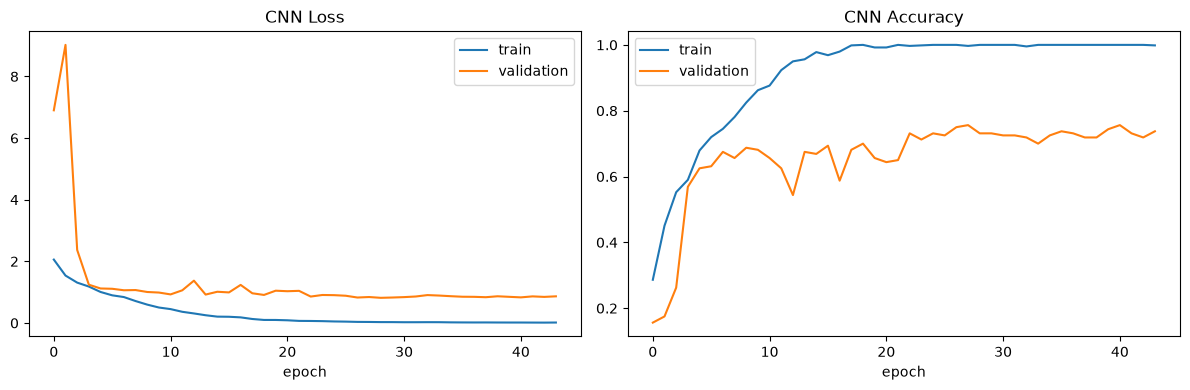

In [19]:
print(f'final_train_accuracy = {cnn_history.history["accuracy"][-1]:.4f}')
print(f'final_val_accuracy = {cnn_history.history["val_accuracy"][-1]:.4f}')
print(f'final_train_loss = {cnn_history.history["loss"][-1]:.4f}')
print(f'final_val_loss = {cnn_history.history["val_loss"][-1]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(cnn_history.history['loss'], label='train')
axes[0].plot(cnn_history.history['val_loss'], label='validation')
axes[0].set_title('CNN Loss'); axes[0].set_xlabel('epoch'); axes[0].legend()
axes[1].plot(cnn_history.history['accuracy'], label='train')
axes[1].plot(cnn_history.history['val_accuracy'], label='validation')
axes[1].set_title('CNN Accuracy'); axes[1].set_xlabel('epoch'); axes[1].legend()
plt.tight_layout(); plt.show()

In [20]:
# Confirm bug fix. There should be a roughly even split among classes, not a large number in one class
print(f'pred_class_counts = {np.bincount(np.argmax(cnn.predict(X_img_val, verbose=0), axis=1), minlength=10)}')

# Same images, but forcing batch statistics instead of the moving averages
print(f'training_mode_val_accuracy = {(np.argmax(cnn(X_img_val, training=True).numpy(), axis=1) == y_img_val).mean():.4f}')

pred_class_counts = [15 19 17 13 13 13 16 16 16 22]
training_mode_val_accuracy = 0.7312


### 2.2.5. CNN: Predictions, Precision, Recall, F1:

In [21]:
# 
# Get the test set numbers in the way that other models were scored on
#

cnn_row, y_pred_cnn, y_score_cnn = evaluate_keras_model(
    cnn, X_img_test, y_img_test, 'CNN (spectrograms)', cnn_training_time)
cnn_row

,Model,Family,Test Accuracy,Precision (macro),Recall (macro),F1 (macro),Macro AUC,Micro AUC,Training Time (s),Tuning Time (s),Complexity,Complexity Measure
0,CNN (spectrograms),Neural Network,0.785,0.788506,0.785,0.783391,0.9645,0.968469,697.303162,NaN,392906,total parameters


#### 2.2.5.1. CNN: Train vs Test Accuracy:

In [22]:
#
# 2.2.5.1: CNN (baseline): Train vs Test Accuracy
#
# Measured the same way as 2.2.7.4 does for the augmented model -- clean training images,
# inference mode -- so the two generalization gaps are directly comparable.

from sklearn.metrics import accuracy_score

genre_labels = list(labelencoder.classes_)

y_pred_cnn_train = np.argmax(cnn.predict(X_img_tr, verbose=0), axis=1)

y_true_tr   = np.asarray(y_img_tr)
y_true_test = np.asarray(y_img_test)

cnn_train_accuracy = accuracy_score(y_true_tr,   y_pred_cnn_train)
cnn_test_accuracy  = accuracy_score(y_true_test, y_pred_cnn)
cnn_accuracy_gap   = cnn_train_accuracy - cnn_test_accuracy

print(f'cnn_train_accuracy = {cnn_train_accuracy:.4f}')
print(f'cnn_test_accuracy  = {cnn_test_accuracy:.4f}')
print(f'cnn_accuracy_gap   = {cnn_accuracy_gap:.4f}')

# One song per genre rather than the first 10, which would all be blues -- the test set
# is sorted by genre
print('\nSample of 10 test predictions:')
sample_idx = np.linspace(0, len(y_true_test) - 1, 10).astype(int)
for i in sample_idx:
    actual    = genre_labels[y_true_test[i]]
    predicted = genre_labels[y_pred_cnn[i]]
    flag      = '' if y_true_test[i] == y_pred_cnn[i] else '   <-- wrong'
    print(f'  actual = {actual:<10} predicted = {predicted:<10}{flag}')


cnn_train_accuracy = 0.9984
cnn_test_accuracy  = 0.7850
cnn_accuracy_gap   = 0.2134

Sample of 10 test predictions:
  actual = blues      predicted = reggae       <-- wrong
  actual = classical  predicted = classical 
  actual = country    predicted = blues        <-- wrong
  actual = disco      predicted = hiphop       <-- wrong
  actual = hiphop     predicted = hiphop    
  actual = jazz       predicted = jazz      
  actual = metal      predicted = rock         <-- wrong
  actual = pop        predicted = pop       
  actual = reggae     predicted = pop          <-- wrong
  actual = rock       predicted = rock      


### 2.2.6. CNN: Confusion Matrix, ROC, and AUC:

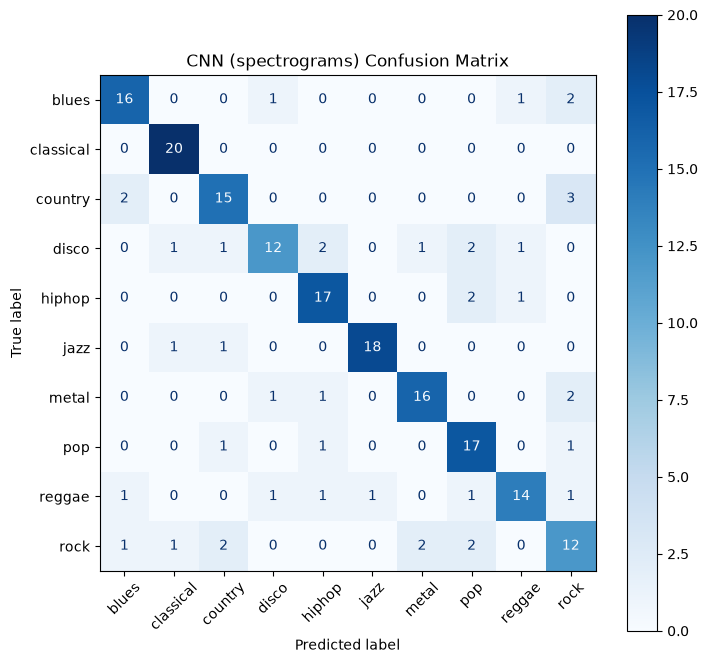

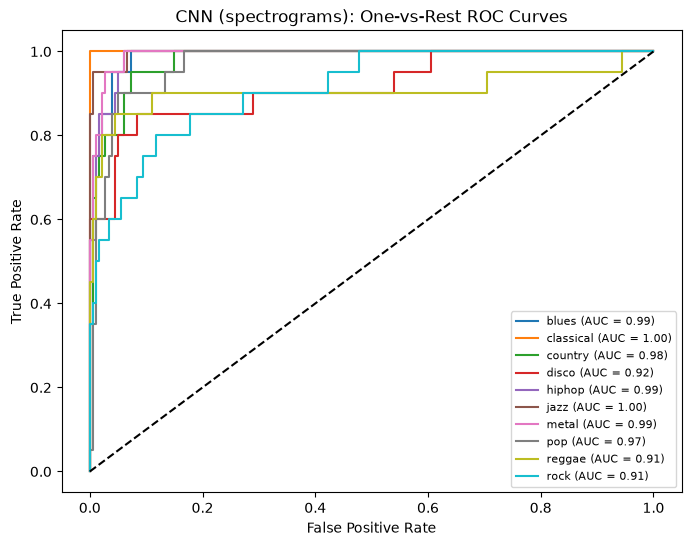

macro_auc = 0.9645
micro_auc = 0.9685


In [23]:
plot_confusion_and_roc(y_img_test, y_pred_cnn, y_score_cnn, 'CNN (spectrograms)')

#### NOTE about Confusion Matrix above:

For category "disco" in the baseline CNN model:

  - 12 on the diagonal — 12 of the 20 true disco songs identified, recall 0.60
  - 15 in the column — the model predicted "disco" 15 times in total, 12 correctly, precision 0.80

Since 15 < 20, the model predicts disco less often than disco actually occurs.

## Summary So Far:

On the identical 200 test songs, the CNN reaches:

* 0.785 accuracy
* 0.7885 macro precision
* 0.785 recall
* 0.7834 macro F1,
* and 0.9645 macro AUC

using 392,906 parameters and ~~735.9~~ 697.3 seconds of training (specific time varies each time the notebook is run)

The full ranking is now:

1. random forest 0.820
2. gradient boosting 0.795
3. CNN 0.785
4. feed-forward neural network (baseline) 0.775
5. SVM 0.765
6. feed-forward neural network (tuned) 0.755 (computed in 2.1.8)
7. k-NN 0.690

The CNN edges past the feed-forward net by one percentage point, but NOTE: one point on 200 samples is two songs, and the standard error is around 2.9 points, so in fact the two neural models are statistically indistinguishable.

Speed of training: the CNN took ~~735.9~~ 697.3 seconds versus the feed-forward net's ~~6~~ 4.64 — ~~an increase by ~116x multiple~~ a 150-fold increase in training time, with only a difference of two correctly classified tracks. And both still lose to a random forest that trained in half a second.

The CNN's macro AUC of 0.9645 is also below both tree approaches.

Does increasing model complexity actually improve performance? on this dataset, no, and the reason is data volume rather than architecture.

A batch normalization bug in first definition of CNN model building made it appear to be a 10% random classifier.

### 2.2.7. CNN with Augmentation

Generate additional training examples by applying transformations to the ones we already have, chosen so the transformation changes the input without changing the correct label. The expectation is for the model to never see the exact same image twice [ but there is a bug in time_augment, fixed below in the second version ], which makes it much harder for it to succeed by memorizing individual training examples and pushes it toward features that survive the perturbations.

In [24]:
AUTOTUNE = tf.data.AUTOTUNE
IMG_H, IMG_W = X_img_tr.shape[1], X_img_tr.shape[2]

def time_augment(img, label, min_frac=0.8, time_width=16, n_masks=2):
    # random slice along time only, then stretch back -- all 128 frequency rows kept
    w  = tf.cast(tf.round(tf.random.uniform([], min_frac, 1.0) * IMG_W), tf.int32)
    x0 = tf.random.uniform([], 0, IMG_W - w + 1, dtype=tf.int32)
    img = tf.image.resize(img[:, x0:x0 + w, :], (IMG_H, IMG_W))

    # optional: blank a few short time spans (set n_masks=0 to skip entirely)
    for _ in range(n_masks):
        size  = tf.random.uniform([], 1, time_width + 1, dtype=tf.int32)
        start = tf.random.uniform([], 0, IMG_W - size, dtype=tf.int32)
        idx   = tf.range(IMG_W)
        keep  = tf.cast(tf.logical_or(idx < start, idx >= start + size), img.dtype)
        img   = img * tf.reshape(keep, [1, -1, 1])

    return tf.ensure_shape(img, (IMG_H, IMG_W, 3)), label


train_ds = (tf.data.Dataset.from_tensor_slices((X_img_tr, y_img_tr))
            .shuffle(len(X_img_tr), seed=42)
            .map(time_augment)  # was: .map(time_augment, num_parallel_calls=AUTOTUNE)
            .batch(32)
            .prefetch(AUTOTUNE))

cnn_aug = build_cnn()          # unchanged builder, same seed, same init

early_stop_aug = EarlyStopping(monitor='val_loss', patience=25,
                               restore_best_weights=True)

aug_start_time = time.time()
aug_history = cnn_aug.fit(train_ds,
                          validation_data=(X_img_val, y_img_val),
                          epochs=200,
                          callbacks=[early_stop_aug],
                          verbose=0)
aug_training_time = time.time() - aug_start_time

/Users/brian/envs/py312/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


#### 2.2.7.1. CNN with Augmentation: Evaluation, Accuracy:

In [25]:
aug_best_epoch = int(np.argmin(aug_history.history['val_loss'])) + 1
print(f'aug_training_time = {aug_training_time:.2f} seconds')
print(f'aug_epochs_run = {len(aug_history.history["loss"])}')
print(f'aug_best_epoch = {aug_best_epoch}')
print(f'aug_val_accuracy_at_best_epoch = {aug_history.history["val_accuracy"][aug_best_epoch - 1]:.4f}')
print(f'final_train_accuracy = {aug_history.history["accuracy"][-1]:.4f}')

cnn_aug_row, y_pred_aug, y_score_aug = evaluate_keras_model(
    cnn_aug, X_img_test, y_img_test, 'CNN (augmented)', aug_training_time)
cnn_aug_row

aug_training_time = 1083.16 seconds
aug_epochs_run = 59
aug_best_epoch = 34
aug_val_accuracy_at_best_epoch = 0.7000
final_train_accuracy = 0.9859


,Model,Family,Test Accuracy,Precision (macro),Recall (macro),F1 (macro),Macro AUC,Micro AUC,Training Time (s),Tuning Time (s),Complexity,Complexity Measure
0,CNN (augmented),Neural Network,0.74,0.770546,0.74,0.733694,0.959694,0.958172,1083.162314,NaN,392906,total parameters


In [26]:
cnn_fixedcrop_row = cnn_aug_row.assign(Model='CNN (fixed crop)')

In [27]:
# one = tf.data.Dataset.from_tensor_slices((X_img_tr[:1], y_img_tr[:1])).map(time_augment)
# imgs = [next(iter(one))[0].numpy() for _ in range(3)]
# print([float(np.abs(imgs[0] - im).mean()) for im in imgs])

one = (tf.data.Dataset.from_tensor_slices((X_img_tr[:1], y_img_tr[:1]))
       .repeat(3)
       .map(time_augment))
imgs = [im.numpy() for im, _ in one]      # one iterator, three elements
print([float(np.abs(imgs[0] - im).mean()) for im in imgs])

[0.0, 0.07035507261753082, 0.06995087116956711]


2026-09-10 13:27:11.081984: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [28]:
rng = tf.random.Generator.from_seed(42)

#
# Fix bug in previous version. Now the model should never see the exact same image twice.
#

def time_augment_version_2(img, label, min_frac=0.8, time_width=16, n_masks=2):
    w  = tf.cast(tf.round(rng.uniform([], min_frac, 1.0) * IMG_W), tf.int32)
    x0 = rng.uniform([], 0, IMG_W - w + 1, dtype=tf.int32)
    img = tf.image.resize(img[:, x0:x0 + w, :], (IMG_H, IMG_W))

    for _ in range(n_masks):
        size  = rng.uniform([], 1, time_width + 1, dtype=tf.int32)
        start = rng.uniform([], 0, IMG_W - size, dtype=tf.int32)
        idx   = tf.range(IMG_W)
        keep  = tf.cast(tf.logical_or(idx < start, idx >= start + size), img.dtype)
        img   = img * tf.reshape(keep, [1, -1, 1])

    return tf.ensure_shape(img, (IMG_H, IMG_W, 3)), label

In [29]:
train_ds = (tf.data.Dataset.from_tensor_slices((X_img_tr, y_img_tr))
            .shuffle(len(X_img_tr), seed=42)
            # .map(time_augment_version_2, num_parallel_calls=AUTOTUNE)
            .map(time_augment_version_2)
            .batch(32)
            .prefetch(AUTOTUNE))

cnn_aug = build_cnn()          # unchanged builder, same seed, same init

early_stop_aug = EarlyStopping(monitor='val_loss', patience=25,
                               restore_best_weights=True)

aug_start_time = time.time()
aug_history = cnn_aug.fit(train_ds,
                          validation_data=(X_img_val, y_img_val),
                          epochs=200,
                          callbacks=[early_stop_aug],
                          verbose=0)
aug_training_time = time.time() - aug_start_time

/Users/brian/envs/py312/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


In [30]:
aug_best_epoch = int(np.argmin(aug_history.history['val_loss'])) + 1
print(f'aug_training_time = {aug_training_time:.2f} seconds')
print(f'aug_epochs_run = {len(aug_history.history["loss"])}')
print(f'aug_best_epoch = {aug_best_epoch}')
print(f'aug_val_accuracy_at_best_epoch = {aug_history.history["val_accuracy"][aug_best_epoch - 1]:.4f}')
print(f'final_train_accuracy = {aug_history.history["accuracy"][-1]:.4f}')
#
# TODO: if above print statements need to be printed multiple times,
# maybe the first time they should have been placed in a helper def method definition? 
# perhaps as a part of / always run with evaluate_keras_model method ???
#

cnn_aug_row, y_pred_aug, y_score_aug = evaluate_keras_model(
    cnn_aug, X_img_test, y_img_test, 'CNN (augmented)', aug_training_time)
cnn_aug_row

aug_training_time = 1556.68 seconds
aug_epochs_run = 59
aug_best_epoch = 34
aug_val_accuracy_at_best_epoch = 0.7563
final_train_accuracy = 0.9859


,Model,Family,Test Accuracy,Precision (macro),Recall (macro),F1 (macro),Macro AUC,Micro AUC,Training Time (s),Tuning Time (s),Complexity,Complexity Measure
0,CNN (augmented),Neural Network,0.76,0.767278,0.76,0.760923,0.964361,0.967764,1556.678257,NaN,392906,total parameters


In [31]:
one = (tf.data.Dataset.from_tensor_slices((X_img_tr[:1], y_img_tr[:1]))
       .repeat(3)
       .map(time_augment_version_2))
imgs = [im.numpy() for im, _ in one]      # one iterator, three elements
print([float(np.abs(imgs[0] - im).mean()) for im in imgs])

[0.0, 0.07440736144781113, 0.063487209379673]


2026-09-10 13:53:12.068562: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [32]:
ds = (tf.data.Dataset.from_tensor_slices((X_img_tr[:1], y_img_tr[:1]))
      .map(time_augment_version_2))
a = [im.numpy() for im, _ in ds][0]      # first pass
b = [im.numpy() for im, _ in ds][0]      # second pass, fresh iterator
print(float(np.abs(a - b).mean()))

0.06673098355531693


2026-09-10 13:53:12.386867: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-09-10 13:53:12.461734: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


#### NOTE:

This run both versions finished at 0.9859 training accuracy, while previous runs had seen a small change (such as frozen 1.0 vs. per epoch 0.9969).

The fixed-crop run scored 0.74 test accuracy against the corrected run's 0.76. On this run the
fixed-crop model reached macro AUC 0.9597 and validation accuracy 0.7000, against 0.9644 and
0.7563 for the corrected run, and the highest macro AUC of any neural model this run belongs
to the baseline CNN at 0.9645. An earlier run had the fixed-crop model leading on both
measures — see the reproducibility note below.

In at least one previous run, "fixing" the augmentation bug actually made the model *WORSE* on every headline metric.
But this reversed on some run(s). Augmentation sometimes helps slightly, sometimes makes things worse. But not a significant consistent help.

Caveat about standard error and noise: 0.74 vs 0.76 (this run, but varies some each execution of the code), which is 4 songs out of 200, within the 2.9-point standard error mentioned elsewhere.

Reproducibility note: The specific values vary when the notebook is re-run with a new kernel. From the current run and previous runs, the values being compared could be 0.76 / 0.74, 0.775 / 0.745, and now 0.74 / 0.76.  Inconsistent, all close to the 0.75, and with no strong case for an improvement.

The following didn't consistently replicate, so is speculative only:

A possible explanation is the same batch-normalization problem that appears throughout this section. A frozen augmentation is effectively one fixed alternative view of each song — a second training set, stable across epochs — so the moving mean and variance can converge to it, and the gap to clean validation images stays bounded. Genuine per-epoch randomization keeps the input distribution moving, so those statistics never settle on anything that matches the clean images used at inference. Augmentation that varies every epoch is the textbook recommendation, but it interacts badly with batch normalization on a dataset this small.

#### 2.2.7.2. CNN with Augmentation: Learning Curve:

final_train_accuracy = 0.9859
final_val_accuracy   = 0.6562
final_train_loss     = 0.0910
final_val_loss       = 1.2300


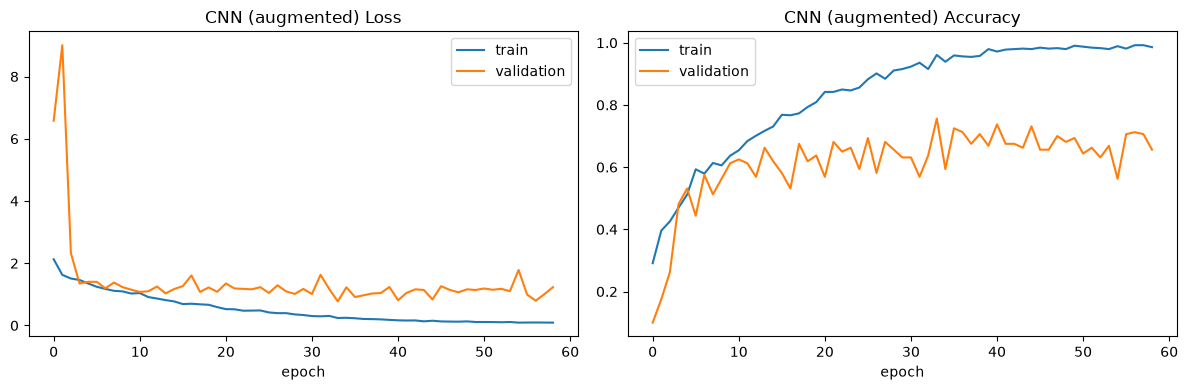

In [33]:
print(f'final_train_accuracy = {aug_history.history["accuracy"][-1]:.4f}')
print(f'final_val_accuracy   = {aug_history.history["val_accuracy"][-1]:.4f}')
print(f'final_train_loss     = {aug_history.history["loss"][-1]:.4f}')
print(f'final_val_loss       = {aug_history.history["val_loss"][-1]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(aug_history.history['loss'], label='train')
axes[0].plot(aug_history.history['val_loss'], label='validation')
axes[0].set_title('CNN (augmented) Loss'); axes[0].set_xlabel('epoch'); axes[0].legend()
axes[1].plot(aug_history.history['accuracy'], label='train')
axes[1].plot(aug_history.history['val_accuracy'], label='validation')
axes[1].set_title('CNN (augmented) Accuracy'); axes[1].set_xlabel('epoch'); axes[1].legend()
plt.tight_layout(); plt.show()

#### NOTE:

Augmentation slowed memorization but didn't prevent it. The baseline reached 0.8 training
accuracy by about epoch 8, 0.9 by epoch 12 and essentially 1.00 by epoch 18, finishing at
training loss 0.0143. The augmented run took until about epoch 13 to reach 0.75, epoch 25 to
reach 0.9, and epoch 40 to settle near 0.98, finishing at training loss 0.0910 — roughly six
times the baseline's — over 59 epochs instead of 44. The augmentations genuinely made the
training set harder to fit. They did not change where it ended up: final training accuracy
0.9859 against 0.9984.

Validation is where the two diverge. The baseline finished at 0.7375 validation accuracy and
0.8646 validation loss; the augmented run finished at 0.6562 and 1.2300. Measured against
validation, the generalization gap is 26 points for the baseline and 33 for the augmented
model. Measured against the test set (section 2.2.7.4) the two are nearly identical, 0.2134
and 0.2103. The two measures disagree because the validation set is 160 songs and the test
set 200, and because validation accuracy is read at the final epoch while the restored
weights come from the best epoch — neither difference is large enough to carry an argument.

Both models show a violent transient in the first two epochs: validation loss opens near 7
and spikes to about 9 at epoch 1 before collapsing below 1.5 by epoch 4. That is not caused
by augmentation. It is batch normalization's moving mean and variance being essentially
untrained during the first inference passes, and it appears in the baseline curve just as
clearly.

What augmentation does change is the behaviour afterwards. The baseline's validation loss
settles into a narrow band around 0.85–0.9 from about epoch 22 and stays there. The augmented
run's oscillates between roughly 0.85 and 1.8 for the entire run, with peaks near epoch 17,
epoch 30 and epoch 53, and its validation accuracy carries a matching sawtooth swinging
between about 0.55 and 0.76 that never settles — against a baseline that holds a much tighter
0.70–0.76 over its final twenty epochs.

Batch normalization is the likely mechanism for that instability too. It accumulates its
moving statistics from the training stream, which is now masked and time-stretched, while the
validation images stay clean. The training distribution keeps moving from epoch to epoch, so
those statistics never settle on anything that matches what the model is evaluated against.

Augmentation delayed convergence, cost 859.4 extra seconds, and did not improve generalization
in any measure. With 639 independent songs and 392,906 parameters, the network memorizes
whatever it is shown, augmented or not.

#### 2.2.7.3. CNN (Augmented): Confusion Matrix, ROC, AUC:

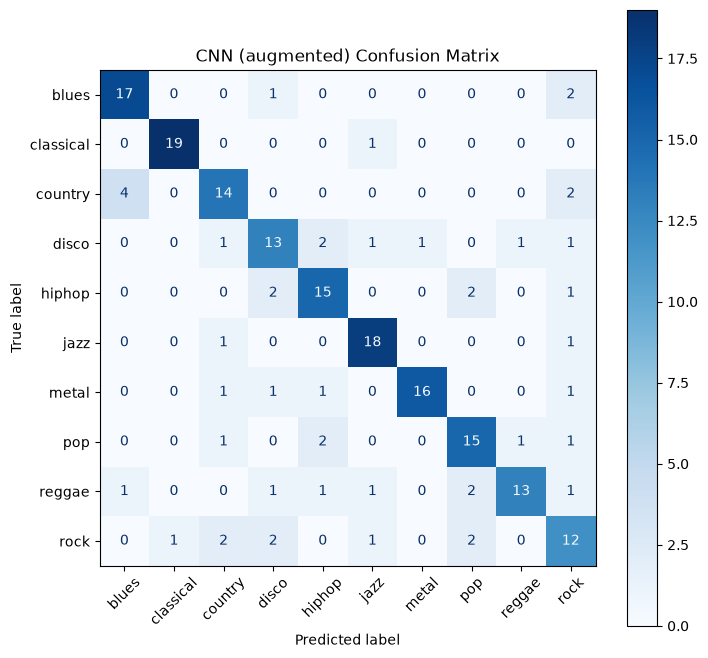

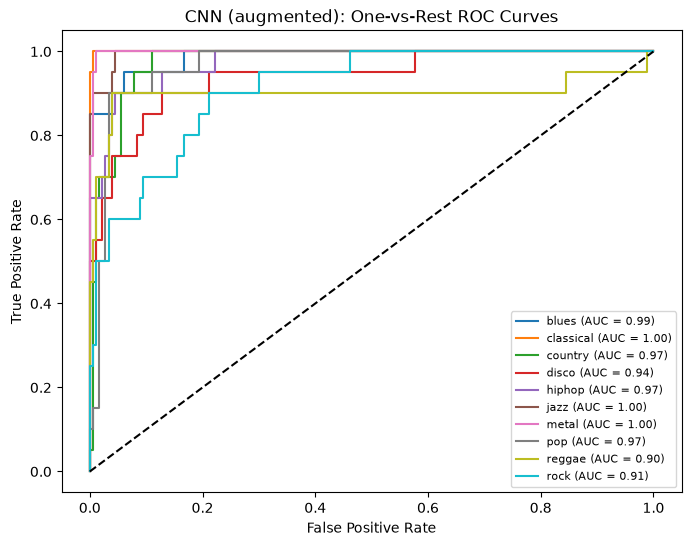

macro_auc = 0.9644
micro_auc = 0.9678


In [34]:
#
# Confusion Matrix and ROC
#

plot_confusion_and_roc(y_img_test, y_pred_aug, y_score_aug, 'CNN (augmented)')

#### NOTE:

The augmented model gets 152 of 200 test songs right (0.760) against the baseline's 157
(0.785) — five songs, well inside the ±2.9-point standard error. Its per-class recall runs
classical 0.95, jazz 0.90, blues 0.85, metal 0.80, hiphop 0.75, pop 0.75, country 0.70,
disco 0.65, reggae 0.65, rock 0.60. The baseline's runs classical 1.00, jazz 0.90, hiphop
0.85, pop 0.85, blues 0.80, metal 0.80, country 0.75, reggae 0.70, disco 0.60, rock 0.60.

**Rock is the consistent failure.** It is the worst class in both models at 0.60 recall, and
it is simultaneously the most over-predicted: the baseline predicts "rock" 21 times for 20
true rock songs with only 12 correct (precision 0.571), and the augmented model predicts it
22 times with 12 correct (precision 0.545). Rock is both the class the model most often
misses and the label it most often reaches for wrongly, and augmentation changes neither.
Its errors scatter — 2 each to country, disco and pop in the augmented model, with no single
dominant confusion — which is what a class the model has no coherent representation for
looks like.  

Its per-class AUC tells the other half of the story: 0.91 in both models, against that same 0.60 recall. The correct
genre is usually ranked plausibly; the model simply rarely picks it first.

**Classical and jazz anchor the other end**, at 0.95/1.00 and 0.90 recall, and neither is
much affected by augmentation. Country is the other persistent problem, confusing
bidirectionally with blues (4 country songs called blues in the augmented model) and with
rock (2 each way).

**A caution about reading too much into this matrix.** An earlier run of this same code
produced a strikingly different error structure: disco absorbed 29 predictions for 20 true
songs and looked like a clear "magnet" class, metal became a secondary magnet, and rock→metal
was the single largest off-diagonal cell at 5. In the current run disco is predicted exactly
20 times for 20 true songs, metal is under-predicted with precision 0.941, and rock→metal is
zero. I had built an explanation for that earlier pattern — that time-cropping distorts
apparent tempo, and disco is the most tempo-defined genre in GTZAN, so blurring tempo should
push tempo-adjacent genres toward disco. It was a plausible mechanism and it fit that matrix
well, but it did not reproduce, and I am recording it here as a hypothesis the data
subsequently failed to support rather than as a finding.

With 20 test songs per genre, a single class's recall moves 0.05 for every song that changes
hands. The per-class structure that survives repeated runs — rock hardest and over-predicted,
classical and jazz easiest, country/blues/rock mutually confused — is worth trusting. The
run-specific detail is not.

#### 2.2.7.4. CNN with Augmentation: Train vs Test Accuracy: 

In [35]:
#
# 2.2.7.4: CNN with Augmentation: Train vs Test Accuracy
#

from sklearn.metrics import accuracy_score

genre_labels = list(labelencoder.classes_)

# clean (un-augmented) training images, inference mode
y_pred_aug_train = np.argmax(cnn_aug.predict(X_img_tr, verbose=0), axis=1)

y_true_tr   = np.asarray(y_img_tr)
y_true_test = np.asarray(y_img_test)

aug_train_accuracy = accuracy_score(y_true_tr,   y_pred_aug_train)
aug_test_accuracy  = accuracy_score(y_true_test, y_pred_aug)

print(f'aug_train_accuracy = {aug_train_accuracy:.4f}')
print(f'aug_test_accuracy  = {aug_test_accuracy:.4f}')
print(f'aug_accuracy_gap   = {aug_train_accuracy - aug_test_accuracy:.4f}')

# print('\nFirst 10 test predictions:')
# for i in range(10):
#     actual    = genre_labels[y_true_test[i]]
#     predicted = genre_labels[y_pred_aug[i]]
#     flag      = '' if y_true_test[i] == y_pred_aug[i] else '   <-- wrong'
#     print(f'  actual = {actual:<10} predicted = {predicted:<10}{flag}')

print('\nSample of 10 test predictions:')
sample_idx = np.linspace(0, len(y_true_test) - 1, 10).astype(int)
for i in sample_idx:
    actual    = genre_labels[y_true_test[i]]
    predicted = genre_labels[y_pred_aug[i]]
    flag      = '' if y_true_test[i] == y_pred_aug[i] else '   <-- wrong'
    print(f'  actual = {actual:<10} predicted = {predicted:<10}{flag}')

aug_train_accuracy = 0.9703
aug_test_accuracy  = 0.7600
aug_accuracy_gap   = 0.2103

Sample of 10 test predictions:
  actual = blues      predicted = blues     
  actual = classical  predicted = classical 
  actual = country    predicted = blues        <-- wrong
  actual = disco      predicted = hiphop       <-- wrong
  actual = hiphop     predicted = hiphop    
  actual = jazz       predicted = jazz      
  actual = metal      predicted = metal     
  actual = pop        predicted = pop       
  actual = reggae     predicted = pop          <-- wrong
  actual = rock       predicted = rock      


#### NOTE: Generalization Gap: Baseline vs. Augmented:

CROSSED OUT NUMBERS ARE FROM A PREVIOUS RUN OF THE NOTEBOOK

Both models measured the same way — clean, un-augmented training images, inference mode:

| | train | test | gap |
|---|---|---|---|
| CNN (baseline) | 0.9984 | 0.7850 | 0.2134 |
| ~~CNN (augmented)~~ | ~~0.9844~~ | ~~0.7450~~ | ~~0.2394~~ |
| CNN (augmented, latest run) | 0.9703 | 0.7600 | 0.2103 |

The gap narrowed this latest run, but in a previous run the augmentation widened the generalization gap rather than closing it. At that time it cost 1.40 points of training accuracy and 4.00 points of test accuracy, and the difference between those two losses is precisely the 2.60-point increase in the gap. The augmentations made the training set harder to fit, which is what they are supposed to do, but the model gave up more on unseen songs than it gave up on seen ones.

A caveat about sample size: the 2.5-point difference in test accuracy is 5 songs, and the
0.31-point difference in the gap itself is far below the noise in either of its components,
against a binomial standard error of about 2.9 points. Neither difference supports a claim in
either direction.

Note that the NOTE under section 2.2.7.2 now shows 26 for the baseline and 33 for the augmented model.  In a previous run these were roughly 26 for both models.  Be aware that those figures were computed against the 160-song validation set, which is what the training history records. The 0.2134 and 0.2103 figures here are computed based against the full 200-song test set. The two measure the same phenomenon on different data.

The ten-song sample displayed in each section is an illustration, not a measurement. This model's draw happens to show 5 of 10 correct against its true 0.785, while the augmented model's draw shows 7 of 10 against its true 0.760 (those values were slightly different on previous runs of the same code) — with ten songs the standard error is about 13 points, so the two displays should not be compared against each other.


### 2.2.8. CNN Hyper-Parameter Tuning:

Previous models were tuned by varying hyper-parameters. To be consistent, let's do that for CNN also here.


In [37]:
#                                                                                                          
# 2.2.8. CNN: Hyper-Parameter Tuning
#
# Reduced budget for the sweep only: 40 epochs / patience 8, against the 100 / 15 used
# for the real training run in 2.2.3. 40 is deliberate -- the 2.2.3 baseline peaked at
# epoch 29, so a tighter cap would truncate the slower 3e-4 configs before their best
# epoch and bias the result toward whichever config just converges fastest.
SWEEP_EPOCHS   = 40
SWEEP_PATIENCE = 8

# 2 x 2 factorial: learning rate against dropout, with the current baseline as one corner
cnn_grid = [
    {'dropout': 0.3, 'learning_rate': 3e-4},   # the 2.2.2 / 2.2.3 baseline
    {'dropout': 0.3, 'learning_rate': 1e-3},
    {'dropout': 0.5, 'learning_rate': 3e-4},
    {'dropout': 0.5, 'learning_rate': 1e-3},
]
                                                                                                             
cnn_sweep_rows = []
cnn_tuning_start_time = time.time()

for i, cfg in enumerate(cnn_grid):
    # No clear_session() call here on purpose: cnn, cnn_aug and their histories are live
    # in this kernel and each costs 10-15 minutes to rebuild if they get invalidated.                      
    candidate = build_cnn(**cfg)          # set_random_seed(42) fires inside the builder,
                                            # so every config starts from identical weights
    es = EarlyStopping(monitor='val_loss', patience=SWEEP_PATIENCE,
                       restore_best_weights=True)

    cfg_start = time.time()
    h = candidate.fit(X_img_tr, y_img_tr,                                                                  
                      validation_data=(X_img_val, y_img_val),
                      epochs=SWEEP_EPOCHS,
                      batch_size=32,
                      callbacks=[es],
                      verbose=0)                                                                           
    cfg_time = time.time() - cfg_start

    best = int(np.argmin(h.history['val_loss']))    # the epoch whose weights were restored
    cnn_sweep_rows.append({
        'idx': i,
        'dropout': cfg['dropout'],                                                                         
        'learning_rate': cfg['learning_rate'],
        'val_accuracy': h.history['val_accuracy'][best],
        'val_loss': h.history['val_loss'][best],
        'best_epoch': best + 1,
        'epochs_run': len(h.history['loss']),
        'seconds': cfg_time,                                                                               
    })

    # verbose=0 means ~8 minutes of silence per config, so report as each one lands
    print(f'config {i + 1}/{len(cnn_grid)}: {cfg} -> '
          f'val_accuracy = {h.history["val_accuracy"][best]:.4f} '
          f'({cfg_time:.0f}s, {len(h.history["loss"])} epochs, best epoch {best + 1})',
          flush=True)

    del candidate                                                                                          

cnn_tuning_time = time.time() - cnn_tuning_start_time
                                                                                                             
# 160 validation songs means accuracy moves in steps of 0.00625, so ties are likely;
# val_loss breaks them rather than leaving the winner up to row order
cnn_tuning_results = (pd.DataFrame(cnn_sweep_rows)
                      .sort_values(['val_accuracy', 'val_loss'], ascending=[False, True])
                      .reset_index(drop=True))

print(f'\ncnn_tuning_time = {cnn_tuning_time:.2f} seconds')
cnn_tuning_results


config 1/4: {'dropout': 0.3, 'learning_rate': 0.0003} -> val_accuracy = 0.7312 (538s, 37 epochs, best epoch 29)
config 2/4: {'dropout': 0.3, 'learning_rate': 0.001} -> val_accuracy = 0.6562 (274s, 20 epochs, best epoch 12)
config 3/4: {'dropout': 0.5, 'learning_rate': 0.0003} -> val_accuracy = 0.7125 (539s, 40 epochs, best epoch 38)
config 4/4: {'dropout': 0.5, 'learning_rate': 0.001} -> val_accuracy = 0.5938 (211s, 15 epochs, best epoch 7)

cnn_tuning_time = 1562.98 seconds


,idx,dropout,learning_rate,val_accuracy,val_loss,best_epoch,epochs_run,seconds
0,0,0.3,0.0003,0.73125,0.815988,29,37,537.679367
1,2,0.5,0.0003,0.71250,0.818178,38,40,539.424606
2,1,0.3,0.0010,0.65625,1.131945,12,20,273.831755
3,3,0.5,0.0010,0.59375,1.165773,7,15,211.094516


In [38]:
#
# 2.2.8 result: the sweep re-selected the configuration already in use.
#
# build_cnn's own defaults are the baseline, so compare against them rather than
# against a hardcoded literal.
import inspect

cnn_defaults = {k: v.default for k, v in inspect.signature(build_cnn).parameters.items()}
best_cnn_cfg = cnn_grid[int(cnn_tuning_results.iloc[0]['idx'])]

print(f'best_cnn_cfg  = {best_cnn_cfg}')
print(f'cnn_defaults  = {cnn_defaults}')
print(f'winner_is_the_baseline = {all(cnn_defaults[k] == v for k, v in best_cnn_cfg.items())}')

# Determinism check: build_cnn seeds at 42, so the winning config in the sweep should
# have reproduced the 2.2.3 training run exactly, despite a different epoch/patience budget.
sweep_best = cnn_tuning_results.iloc[0]
print(f'\n2.2.3 run:  best_epoch = {cnn_best_epoch:2d}, '
      f'val_accuracy = {cnn_history.history["val_accuracy"][cnn_best_epoch - 1]:.5f}')
print(f'sweep run:  best_epoch = {int(sweep_best["best_epoch"]):2d}, '
      f'val_accuracy = {sweep_best["val_accuracy"]:.5f}')

# No separate "CNN (tuned)" row: retraining the winner would restore the same epoch-29
# weights and duplicate cnn_row in every column but training time. Record the cost of
# the search against the existing CNN row instead.
cnn_row['Tuning Time (s)'] = cnn_tuning_time

print(f'\ncnn_training_time = {cnn_training_time:.2f} s   (this kernel, from 2.2.3)')
cnn_row


best_cnn_cfg  = {'dropout': 0.3, 'learning_rate': 0.0003}
cnn_defaults  = {'dropout': 0.3, 'learning_rate': 0.0003, 'bn_momentum': 0.9}
winner_is_the_baseline = True

2.2.3 run:  best_epoch = 29, val_accuracy = 0.73125
sweep run:  best_epoch = 29, val_accuracy = 0.73125

cnn_training_time = 697.30 s   (this kernel, from 2.2.3)


,Model,Family,Test Accuracy,Precision (macro),Recall (macro),F1 (macro),Macro AUC,Micro AUC,Training Time (s),Tuning Time (s),Complexity,Complexity Measure
0,CNN (spectrograms),Neural Network,0.785,0.788506,0.785,0.783391,0.9645,0.968469,697.303162,1562.980071,392906,total parameters


#### NOTE: Tuning Results

The hyper-parameter tuning varied learning rate and dropout across a 2 x 2 grid, scoring each configuration on the same 160-song validation split used everywhere else in 2.2, and selected dropout 0.3 / learning rate 3e-4 — the configuration already chosen by hand in 2.2.2.

The feed-forward sweep in 2.1.8 did the same thing, selecting its own baseline.

Learning rate was the only factor that clearly mattered. Averaged over dropout, 3e-4 scored 0.7219 against 1e-3's 0.6250, a gap of 9.7 points. The two 1e-3 runs also peaked almost immediately, at epochs 7 and 12, and finished with validation loss of 1.17 and
1.13 against roughly 0.82 for the slower pair. At this data volume 1e-3 converges quickly and to a worse place.

Dropout barely registered. Averaged over learning rate it favors 0.3 by 4.1 points, but most of that comes from the high-learning-rate pair. At 3e-4, the learning rate actually in use, dropout 0.3 versus 0.5 is 0.73125 against 0.71250 — three songs out of 160, with
validation losses of 0.8160 and 0.8182 that are effectively identical. The standard error on a single configuration's validation accuracy here is about 3.5 points, so the top two configurations are statistically indistinguishable and the winner was settled by the
validation-loss tiebreak on a margin of 0.0022.

One caveat on that runner-up: the dropout 0.5 / 3e-4 configuration reached its best epoch at 38 and then hit the 40-epoch sweep cap rather than early-stopping, unlike the other three. Its 0.71250 is a lower bound, and a longer budget might have closed the three-song
gap. The reduced epoch budget was a deliberate cost tradeoff, and it happened to bind on the one configuration that needed the most epochs.

The winning configuration reproduced the 2.2.3 training run exactly — best epoch 29, validation accuracy 0.73125 — despite running under a different epoch and patience budget.  Since `build_cnn` seeds at 42, retraining the winner at full settings would restore the
same weights and produce a duplicate of the existing CNN row.

No separate "CNN (tuned)" model is therefore reported; the tuning time is recorded against the CNN row instead.

The search cost ~~1,735.6 seconds, or 28.9 minutes~~ 1,562.98 seconds, or 26.0 minutes, which makes it the second most expensive tuning run in this project after Gradient Boosting's 3,235 seconds, and it bought no improvement. That is now the third experiment in Part 2 to reach the same conclusion:
hyper-parameter tuning, data augmentation, and added architectural capacity all failed to move test accuracy, because the binding constraint is 639 independent training recordings rather than anything about the model.


## 2.3. CNN-LSTM (also using the same spectrogram arrays):

### 2.3.1. CNN-LSTM: Build the Model - Define and Compile:

In [39]:
# CNN-LSTM hybrid: convolutions extract local time-frequency features, then an LSTM
# reads them as a sequence along the time axis of the spectrogram
def build_cnn_lstm(lstm_units=64, dropout=0.3, learning_rate=3e-4, bn_momentum=0.9):
    tf.keras.utils.set_random_seed(42)

    inputs = layers.Input(shape=X_img_train.shape[1:])       # (freq=128, time=128, 3)
    x = inputs

    # Pool frequency aggressively but keep time resolution, so the LSTM gets enough steps.
    # The last block pools (4, 1): 4x on frequency, none on time.
    for filters, pool in [(32, (2, 2)), (64, (2, 2)), (128, (4, 1))]:
        x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
        x = layers.BatchNormalization(momentum=bn_momentum)(x)
        x = layers.MaxPooling2D(pool)(x)

    # x is now (freq=8, time=32, 128). Swap axes so time is axis 1 -- the sequence dimension.
    x = layers.Permute((2, 1, 3))(x)                          # -> (time=32, freq=8, 128)

    # Flatten frequency and channels into one feature vector per time step
    x = layers.Reshape((x.shape[1], x.shape[2] * x.shape[3]))(x)   # -> (32, 1024)

    # Bidirectional so each time step sees context from both earlier and later in the track
    x = layers.Bidirectional(layers.LSTM(lstm_units))(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    cnn_lstm = models.Model(inputs, outputs)
    cnn_lstm.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])
    return cnn_lstm

cnn_lstm = build_cnn_lstm()
cnn_lstm.summary()
print(f'cnn_lstm_total_params = {cnn_lstm.count_params()}')

Model: "functional_166"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_16 (InputLayer)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_38 (MaxPooling2D) │ (None, 8, 32, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ permute (Permute)               │ (None, 32, 8, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 32, 1024)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │       557,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 653,002 (2.49 MB)

 Trainable params: 652,554 (2.49 MB)

 Non-trainable params: 448 (1.75 KB)

cnn_lstm_total_params = 653002


### 2.3.2. CNN-LSTM: Training:

In [40]:
# Train the hybrid, reusing the stratified validation split built in 2.2
early_stop_hybrid = EarlyStopping(monitor='val_accuracy', mode='max',
                                 patience=20, restore_best_weights=True)

hybrid_start_time = time.time()
hybrid_history = cnn_lstm.fit(X_img_tr, y_img_tr,
                              validation_data=(X_img_val, y_img_val),
                              epochs=100,
                              batch_size=32,
                              callbacks=[early_stop_hybrid],
                              verbose=0)
hybrid_end_time = time.time()
hybrid_training_time = hybrid_end_time - hybrid_start_time
hybrid_best_epoch = int(np.argmax(hybrid_history.history['val_accuracy'])) + 1

print(f'hybrid_training_time = {hybrid_training_time:.2f} seconds')
print(f'hybrid_epochs_run = {len(hybrid_history.history["loss"])}')
print(f'hybrid_best_epoch = {hybrid_best_epoch}')
print(f'hybrid_val_accuracy_at_best_epoch = {hybrid_history.history["val_accuracy"][hybrid_best_epoch - 1]:.4f}')

hybrid_training_time = 587.42 seconds
hybrid_epochs_run = 44
hybrid_best_epoch = 24
hybrid_val_accuracy_at_best_epoch = 0.6812


### 2.3.3. CNN-LSTM: Learning Curves:

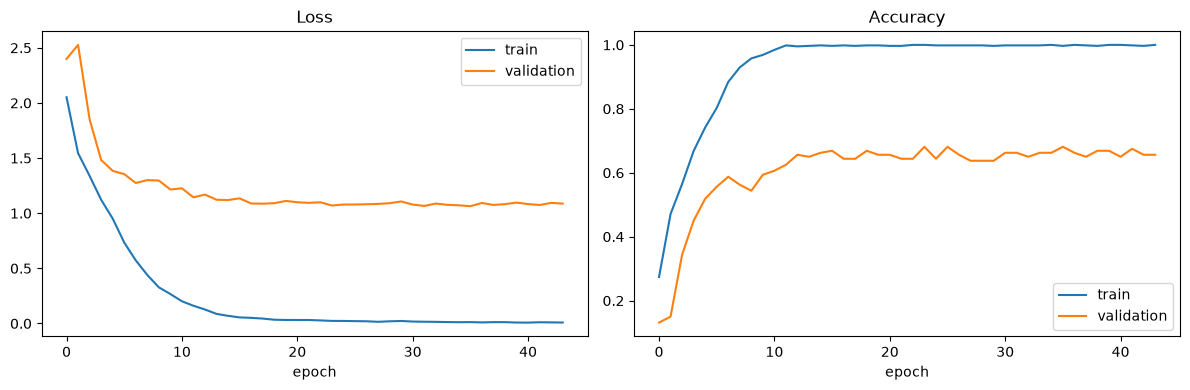

best_epoch = 24 of 44
val_accuracy_at_best_epoch = 0.6812


In [41]:
# Learning curves: check for overfitting and confirm early stopping chose a sensible epoch

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hybrid_history.history['loss'], label='train')
axes[0].plot(hybrid_history.history['val_loss'], label='validation')
axes[0].set_title('Loss'); axes[0].set_xlabel('epoch'); axes[0].legend()
axes[1].plot(hybrid_history.history['accuracy'], label='train')
axes[1].plot(hybrid_history.history['val_accuracy'], label='validation')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('epoch'); axes[1].legend()
plt.tight_layout(); plt.show()

print(f'best_epoch = {hybrid_best_epoch} of {len(hybrid_history.history["loss"])}')
print(f'val_accuracy_at_best_epoch = {hybrid_history.history["val_accuracy"][hybrid_best_epoch - 1]:.4f}')

In [42]:
hybrid_row, y_pred_hybrid, y_score_hybrid = evaluate_keras_model(cnn_lstm, X_img_test, y_img_test, 'CNN-LSTM (spectrograms)', hybrid_training_time)
hybrid_row

,Model,Family,Test Accuracy,Precision (macro),Recall (macro),F1 (macro),Macro AUC,Micro AUC,Training Time (s),Tuning Time (s),Complexity,Complexity Measure
0,CNN-LSTM (spectrograms),Neural Network,0.7,0.700864,0.7,0.692958,0.939667,0.944347,587.417428,NaN,653002,total parameters


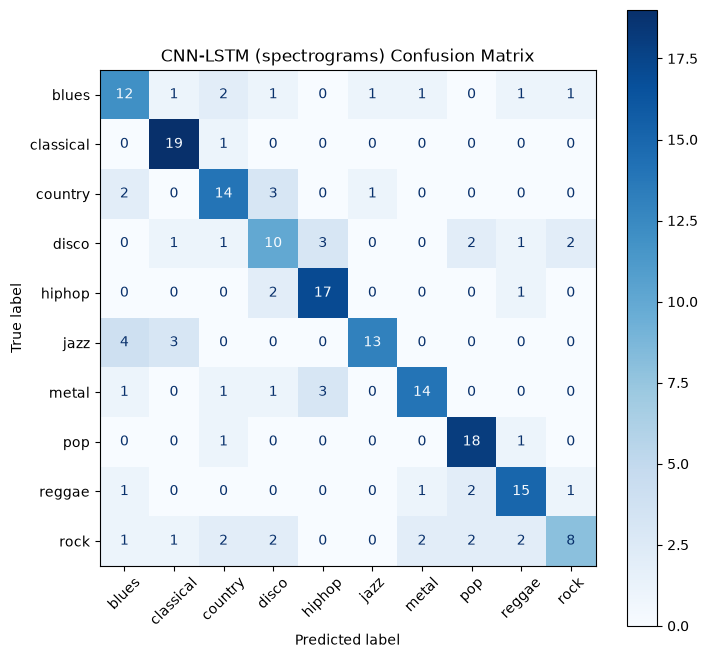

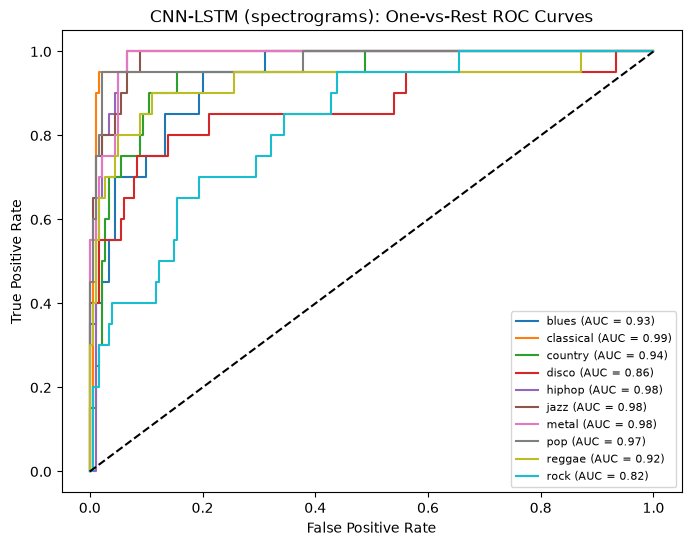

macro_auc = 0.9397
micro_auc = 0.9443


In [43]:
#
# Confusion Matrix and ROC
#

plot_confusion_and_roc(y_img_test, y_pred_hybrid, y_score_hybrid, 'CNN-LSTM (spectrograms)')

## 2.4. Comparison of Models:

### 2.4.1. Combined Table:

In [44]:
# Complete table

results = pd.concat([part1_results, nn_row, nn_tuned_row, cnn_row,
                     cnn_fixedcrop_row, cnn_aug_row, hybrid_row],
                    ignore_index=True)
results = results.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
results.to_csv('all_results.csv', index=False)
print(f'results.shape = {results.shape}') # expected to be results.shape = (10, 12).
results

results.shape = (10, 12)


,Model,Family,Test Accuracy,Precision (macro),Recall (macro),F1 (macro),Macro AUC,Micro AUC,Training Time (s),Tuning Time (s),Complexity,Complexity Measure
0,Random Forest,Classical ML,0.820,0.820470,0.820,0.818040,0.975306,0.976993,0.497786,106.945784,75074,decision nodes
1,Gradient Boosting,Classical ML,0.795,0.802499,0.795,0.794836,0.978222,0.978806,9.974431,3234.812495,2076,decision nodes
2,CNN (spectrograms),Neural Network,0.785,0.788506,0.785,0.783391,0.964500,0.968469,697.303162,1562.980071,392906,total parameters
3,Feed-Forward NN,Neural Network,0.775,0.779030,0.775,0.771468,0.962278,0.964769,4.643466,NaN,49290,total parameters
4,SVM,Classical ML,0.765,0.768611,0.765,0.764319,0.943611,0.945317,0.032251,11.890773,38454,support vectors x features
5,CNN (augmented),Neural Network,0.760,0.767278,0.760,0.760923,0.964361,0.967764,1556.678257,NaN,392906,total parameters
6,Feed-Forward NN (tuned),Neural Network,0.755,0.759568,0.755,0.753195,0.957889,0.961458,4.532375,36.290246,49290,total parameters
7,CNN (fixed crop),Neural Network,0.740,0.770546,0.740,0.733694,0.959694,0.958172,1083.162314,NaN,392906,total parameters
8,CNN-LSTM (spectrograms),Neural Network,0.700,0.700864,0.700,0.692958,0.939667,0.944347,587.417428,NaN,653002,total parameters
9,k-NN,Classical ML,0.690,0.707873,0.690,0.690255,0.905028,0.905900,0.002672,0.396208,800,stored samples


### 2.4.2. Comparison Charts:

#### 2.4.2.1. Side-by-side accuracy and macro F1 for every model

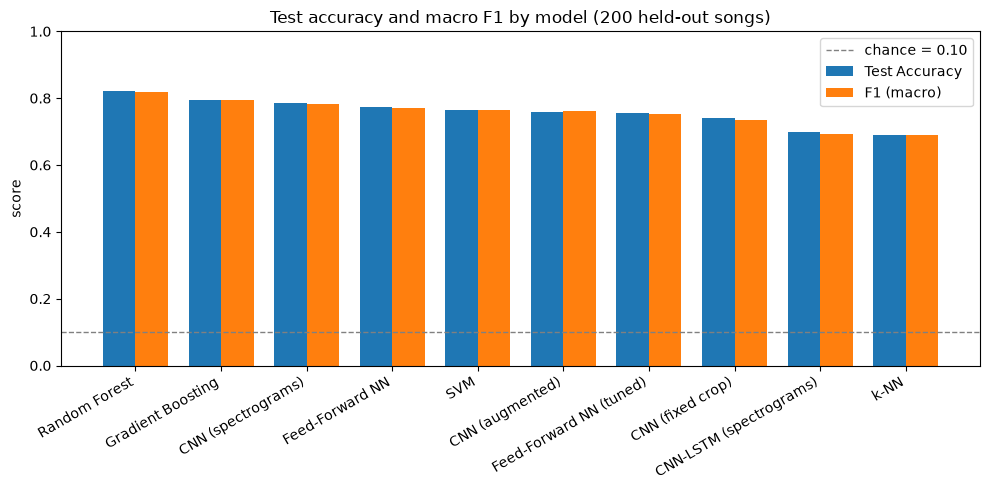

In [45]:
# 2.4.2.1. Side-by-side accuracy and macro F1 for every model

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(results))    # one tick position per model, in ranked order
width = 0.38                   # leaves a visible gap between each accuracy/F1 pair

ax.bar(x - width/2, results['Test Accuracy'], width, label='Test Accuracy')
ax.bar(x + width/2, results['F1 (macro)'], width, label='F1 (macro)')

# 0.10 is what blind guessing would score on ten equally sized genres
ax.axhline(0.10, color='gray', linestyle='--', linewidth=1, label='chance = 0.10')

ax.set_xticks(x)
ax.set_xticklabels(results['Model'], rotation=30, ha='right')
ax.set_ylabel('score')
ax.set_ylim(0, 1.0)
ax.set_title('Test accuracy and macro F1 by model (200 held-out songs)')
ax.legend()
plt.tight_layout()
plt.show()

#### 2.4.2.2. Accuracy against training cost, coloured by model family

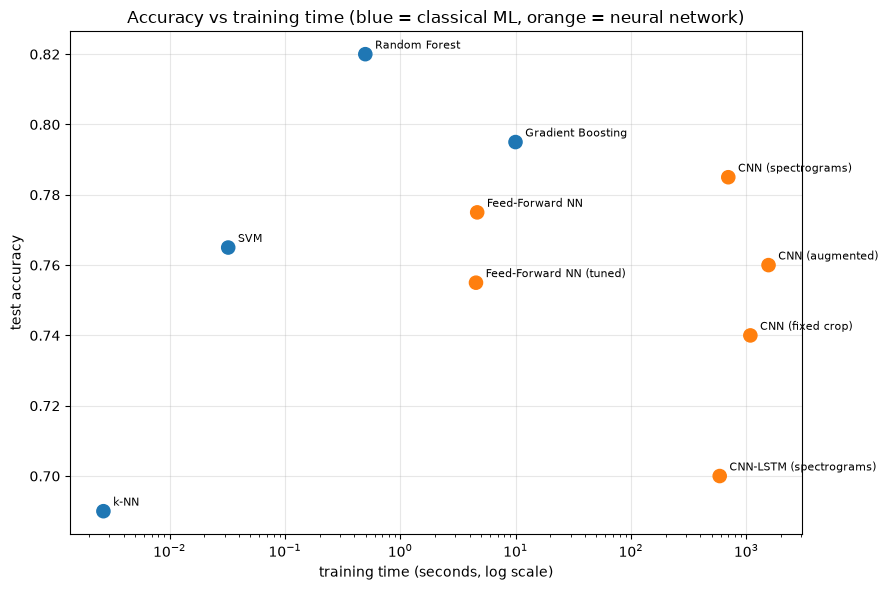

In [46]:
# 2.4.2.2. Accuracy against training cost, coloured by model family

fig, ax = plt.subplots(figsize=(9, 6))

# Map the Family column to colours so the classical/neural split is obvious
family_colors = results['Family'].map({'Classical ML': 'tab:blue',
                                       'Neural Network': 'tab:orange'})
ax.scatter(results['Training Time (s)'], results['Test Accuracy'],
           c=family_colors, s=90, zorder=3)

# Label each marker, offset a few points so the text clears the dot
for _, row in results.iterrows():
    ax.annotate(row['Model'], (row['Training Time (s)'], row['Test Accuracy']),
                textcoords='offset points', xytext=(7, 4), fontsize=8)

ax.set_xscale('log')    # times span 0.003 s to 607 s, so a linear axis is unreadable
ax.set_xlabel('training time (seconds, log scale)')
ax.set_ylabel('test accuracy')
ax.set_title('Accuracy vs training time (blue = classical ML, orange = neural network)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### 2.4.2.3. Quantify to what extent test-set sampling noise was a factor:

In [47]:
# Quantify how much of the spread in the table is just test-set sampling noise

n_test = len(y_test)
p_hat = results['Test Accuracy'].max()                     # best observed accuracy
se = np.sqrt(p_hat * (1 - p_hat) / n_test)                 # binomial standard error

print(f'n_test = {n_test}')
print(f'best_accuracy = {p_hat:.4f}')
print(f'standard_error = {se:.4f}')
print(f'margin_95_percent = {1.96 * se:.4f}')

n_test = 200
best_accuracy = 0.8200
standard_error = 0.0272
margin_95_percent = 0.0532


### 2.4.3. Complexity:

Complexity column mixes decision nodes, support-vectors-times-features, stored samples and total parameters, so it is not a single scale.

Note that it is only comparable within a family, and not across different types of models.

### 2.4.4. Closing Discussion:

Ten models were trained across the two notebooks: four classical algorithms on 58 engineered
audio features, and six neural networks on either those same features or the mel-spectrogram
images. The best of them is a Random Forest at 0.820 test accuracy, trained in about half a
second. The worst is k-Nearest Neighbors at 0.690. Nothing in between is as clearly separated
as the table's ordering makes it look.

**Most of the ranking is sampling noise.**

With 200 test songs, the binomial standard error on
any single accuracy is about 2.9 points and the 95% margin is ±5.3. Random Forest at 0.820,
Gradient Boosting at 0.795, the CNN at 0.785, the feed-forward network at 0.775 and SVM at
0.765 are separated by a total of 11 songs across the whole spread. Treating that ordering as a
ranking of algorithms would be over-reading the data. Only k-NN (0.690) and the CNN-LSTM
(0.700) are far enough back — 26 and 24 songs behind the leader — to call clearly worse.

**Cost does not track accuracy, and neither does complexity.** The Random Forest reached the
best accuracy in roughly half a second; the CNN took 697.3 seconds, more than a
thousand times longer, to land 3.5 points behind it. Complexity moves the same way. Gradient
Boosting, with 2,076 decision nodes, beat the CNN's 392,906 parameters, and the CNN-LSTM's
653,002 parameters — the largest model in the project — produced the worst neural result at
0.700. Across this dataset, added capacity bought nothing and frequently cost something.

**Three independent experiments in Part 2 reached the same conclusion.** Hyper-parameter tuning was run twice: the feed-forward sweep in 2.1.8 selected the configuration already chosen by hand, and the tuned model then scored *worse* on test (0.755 against 0.775); the CNN sweep in 2.2.8 also re-selected its own baseline after 1,562.98 seconds of search. 

Data augmentation in 2.2.7 cost test accuracy in every run and moved the generalization gap inconsistently — wider in one run, marginally narrower in another.

Added architecture in the form of the CNN-LSTM hybrid produced the worst neural score. Three different levers — optimization, data variety, and capacity — all failed to move the number.

**The per-class structure is the most robust finding here**, because it does not depend on which model is used. Rock and disco are the hardest genres for every model in both families.  Classical is the easiest for every model, with pop and jazz close behind, with the CNN identifying all 20 classical test songs correctly. Rock's errors scatter across country, metal and pop rather than concentrating on one neighbour, and its per-class AUC of 0.91 stays far above its 0.60 recall.  The correct genre is usually ranked plausibly; the model simply rarely picks it first. That pattern points at the data rather than the algorithms: these genres genuinely overlap in the feature space, and no amount of model sophistication separates categories that aren't separated in the input.

**This is consistent with published work on the same dataset.** Akhtar and Mishra
(arXiv:2509.01762, September 2025) [1] compare feature-based learning with traditional classifiers
against end-to-end learning with a CNN on GTZAN, and report that a Support Vector Machine
trained on engineered audio features achieved their highest classification performance. Their
explanation is the one this project arrived at independently: on moderately-sized datasets the
strong inductive bias of expert-engineered features can be more beneficial than the end-to-end
paradigm of a CNN, which is prone to overfitting. My CNN's 0.9984 training accuracy against
0.7850 on test is exactly that overfitting.

The agreement is at the level of model family rather than specific algorithm. Their best
classical model was an SVM; here SVM placed fifth at 0.765 and Random Forest led at 0.820.
That difference is itself within the ±5.3-point margin, and the shared conclusion — that the
CNN's additional capacity is a liability at this data volume — does not depend on which
classical model happens to come first.

**Limitations.** Every number here rests on a single 800/200 split with no cross-validation, so all of the estimates carry
the ±5.3-point margin discussed above and none of them are averaged over repeated draws. The augmented CNN runs are not
even reproducible between runs of this notebook: repeated top-to-bottom executions after a kernel restart gave test
accuracies spanning 0.74 to 0.775 for the same code, which is a direct measurement of how much run-to-run noise sits
under every figure in the comparison table. GTZAN itself is known to contain duplicate recordings, some mislabeled
tracks, and artist leakage between splits, all of which inflate apparent accuracy. The CNN inputs are pre-rendered
spectrogram PNGs rather than spectrograms computed from the raw audio, which fixes the time-frequency resolution and
colour mapping outside my control.

**What's next / What would actually help:** 

If I had more time to continue this work, there are additional steps that could be tried including other algorithms, other data sets, and other ways of manipulating the data.

The binding constraint throughout has been 639 independent training recordings against models with hundreds of thousands of parameters. Three things would address that directly, and none of them are architectural: using the 3-second segment features (9,990 rows instead of 999) with a song-level split to avoid leakage between segments of the same track; transfer learning from a pretrained image backbone, which is the standard remedy for small-data CNN training and was not tested here; and soft-voting across the existing diverse models, which costs nothing to train and would test whether their errors are correlated. Each attacks the data problem rather than the model, which is where the evidence points.

**A cautionary comparison.** Boyina et al. (2022) [2] run a similar model comparison on GTZAN and report much higher numbers:
SVM with an RBF kernel at 94.2%, XGBoost and tuned k-NN both around 90%, against my 0.765 and 0.690 for those same two
algorithms. The difference is not the models, it is the unit of analysis. Their PCA plot is labelled "3 sec sample of
all audio files", so they worked from GTZAN's 3-second segments — roughly 9,990 rows rather than 999. The article does
not state whether the train/test split was made at song level or segment level, but the results are characteristic of
the latter: ten consecutive 3-second windows cut from the same recording are nearly identical in feature space, so if
they are scattered across train and test a classifier can identify the specific recording rather than the genre.

Their k-NN result is the clearest symptom. A nearest-neighbour classifier reaching 90% means the nearest neighbour of a
typical test point is usually another slice of the same track, which is a lookup table rather than genre recognition.
On the same features their MLP — which cannot exploit that shortcut as directly — reached only 0.607 on test, below
every model in this project except k-NN. In their favour, they used 10-fold cross-validation where every number in this
project rests on a single split, so their estimates are better averaged than mine even if the split protocol inflates
them.

This is why section 2.2.1 reproduces the exact 800/200 song-level split from Part 1 rather than splitting the
spectrogram images directly. It costs roughly twelve accuracy points against the segment-level figures widely quoted
for GTZAN, and it is the more defensible number. It also sharpens the recommendation above: the 3-second features are
worth using for the extra data, but only with a song-level split, and the gap between the two protocols is a good
measure of how much of the published GTZAN literature is measuring memorization.

**References:**

[1] Ryyan Akhtar and Alokit Mishra, Music Genre Classification Using Machine Learning Techniques, arXiv:2509.01762 (1 September 2025), Bhagwan Parshuram Institute of Technology, New Delhi.

[2] Ashita Boyina, Rahul Dahiya, Sai Chandan and Arunim Gupta, "Music Genre Classification", Medium, 8 January 2022.
  https://medium.com/@ashitaboyina/music-genre-classification-70ae70469403 — code at github.com/ashcode028/Music-Genre-Classification

